<a href="https://colab.research.google.com/github/remideso/remideso.github.io/blob/main/BeltLineCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/remideso/remideso.github.io/blob/main/BeltLineCapstone.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Tracks of Change: Race, Space, and the Atlanta BeltLine**

This capstone looks at how proximity to the Atlanta BeltLine relates to housing costs and racial composition across Atlanta census tracts.

The main story I am telling is that redevelopment is not just about trails, green space, and investment. It also changes who can afford to stay in a neighborhood. By looking at census tract data from 2000, 2010, and 2020, I use data to show how housing costs and racial composition shifted over time, especially near the BeltLine.

This notebook is my statistical analysis and data preparation section. Before building predictive models, I wanted to understand the structure of the data, test whether the differences were statistically meaningful, and check for issues that could affect future machine learning models.

Unlike a simple one-year analysis, this notebook is organized around time. The goal is to compare 2000, 2010, and 2020 so the results match the larger timeline story of my capstone.


# **Problem Statement**

The Atlanta BeltLine is often presented as a redevelopment success story because it brings trails, parks, public art, and new investment into the city. But redevelopment does not impact everyone equally.

In historically Black neighborhoods, rising rents and home values can create pressure for long-term residents, especially when investment makes the area more attractive to higher-income households. This project asks whether neighborhoods closer to the BeltLine are experiencing patterns that point toward rising housing costs and demographic change over time.

The larger question is not just whether the BeltLine created growth. The question is who benefits from that growth and who may be pushed out by it.


# **Research Question**

How does proximity to the Atlanta BeltLine relate to housing costs and racial composition in Atlanta from 2000 to 2020?

More specifically, I am looking at:

- how income, home value, and rent changed from 2000 to 2010 to 2020
- whether areas closer to the BeltLine changed differently from areas farther away
- whether racial composition differs by distance from the BeltLine in each year
- whether rent, income, home value, race, and distance are statistically related by year
- whether the dataset has issues that need to be handled before machine learning


# **Data Definition**

This dataset includes census tract-level data for Atlanta across three time points: 2000, 2010, and 2020. It combines demographic, housing, economic, and spatial variables.

The final dataset has **854 rows** and **24 original columns**.

Important variables include:

- `year`: census/ACS year
- `median_income`: median household income
- `median_home_value`: median owner-occupied home value
- `median_gross_rent`: median gross rent
- `pct_black`: percent of residents who are Black
- `pct_white`: percent of residents who are White
- `pct_hispanic`: percent of residents who are Hispanic
- `pct_renter`: percent of occupied housing units that are renter occupied
- `poverty_rate`: percent of population below poverty
- `centroid_distance_miles`: tract centroid distance from the BeltLine
- `beltline_half_mile`: tract is within 0.5 miles of the BeltLine
- `beltline_one_mile`: tract is within 1 mile of the BeltLine
- `beltline_three_miles`: tract is within 3 miles of the BeltLine

The year variable is important because this capstone is about change over time. So most of the analysis below separates results for 2000, 2010, and 2020 instead of mixing all years together.


In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# statistical tests
from scipy.stats import ttest_ind, f_oneway, pearsonr

# regression and multicollinearity
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# machine learning prep
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the dataset from github

df = pd.read_csv('https://raw.githubusercontent.com/remideso/remideso.github.io/main/atlanta_spatial_final.csv')

# preview the data
df.head()

,tract_id,tract_name,total_pop,median_income,median_home_value,median_gross_rent,occupied_units,owner_units,renter_units,hispanic_pop,white_pop,black_pop,poverty_universe,below_poverty,poverty_rate,year,centroid_distance_miles,beltline_half_mile,beltline_one_mile,beltline_three_miles,pct_white,pct_black,pct_hispanic,pct_renter
0,13089020100,"Census Tract 201, DeKalb County, Georgia",1783.0,96542.0,372400.0,808.0,759,546,213,192.0,1500.0,41.0,1782.0,84.0,0.047138,2000,1.533807,0.0,0.0,1.0,0.841279,0.022995,0.107684,0.280632
1,13089020200,"Census Tract 202, DeKalb County, Georgia",2198.0,56094.0,438100.0,730.0,1255,528,727,68.0,1907.0,132.0,2182.0,140.0,0.064161,2000,1.297543,0.0,0.0,1.0,0.867607,0.060055,0.030937,0.579283
2,13089020300,"Census Tract 203, DeKalb County, Georgia",3257.0,73715.0,260500.0,691.0,1510,1025,485,72.0,2540.0,490.0,3253.0,321.0,0.098678,2000,1.724488,0.0,0.0,1.0,0.779859,0.150445,0.022106,0.321192
3,13089020400,"Census Tract 204, DeKalb County, Georgia",2124.0,47438.0,259500.0,729.0,1166,561,605,71.0,1856.0,120.0,2137.0,147.0,0.068788,2000,0.880254,0.0,1.0,1.0,0.873823,0.056497,0.033427,0.518868
4,13089020500,"Census Tract 205, DeKalb County, Georgia",3203.0,28147.0,84200.0,530.0,1183,579,604,94.0,232.0,2833.0,3263.0,857.0,0.262642,2000,0.889622,0.0,1.0,1.0,0.072432,0.884483,0.029347,0.510566


In [3]:
# check the size of the dataset

df.shape

(854, 24)

In [4]:
# check columns and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 854 entries, 0 to 853
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tract_id                 854 non-null    int64  
 1   tract_name               854 non-null    object 
 2   total_pop                854 non-null    float64
 3   median_income            837 non-null    float64
 4   median_home_value        819 non-null    float64
 5   median_gross_rent        799 non-null    float64
 6   occupied_units           854 non-null    int64  
 7   owner_units              854 non-null    int64  
 8   renter_units             854 non-null    int64  
 9   hispanic_pop             854 non-null    float64
 10  white_pop                854 non-null    float64
 11  black_pop                854 non-null    float64
 12  poverty_universe         851 non-null    float64
 13  below_poverty            851 non-null    float64
 14  poverty_rate             8

In [5]:
# check which years are included

df['year'].value_counts().sort_index()

,count
year,
2000,134
2010,192
2020,528


In [6]:
# split the data by year

df_2000 = df[df['year'] == 2000].copy()
df_2010 = df[df['year'] == 2010].copy()
df_2020 = df[df['year'] == 2020].copy()

df_2000.shape, df_2010.shape, df_2020.shape

((134, 24), (192, 24), (528, 24))

In [7]:
# create distance groups for comparison

bins = [0, 0.5, 1, 1.5, 3, 5, 10, np.inf]

labels = [
    '0-0.5 miles',
    '0.5-1 mile',
    '1-1.5 miles',
    '1.5-3 miles',
    '3-5 miles',
    '5-10 miles',
    '10+ miles'
]

df['distance_group'] = pd.cut(
    df['centroid_distance_miles'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_2000 = df[df['year'] == 2000].copy()
df_2010 = df[df['year'] == 2010].copy()
df_2020 = df[df['year'] == 2020].copy()

df[['tract_id', 'year', 'centroid_distance_miles', 'distance_group']].head()

,tract_id,year,centroid_distance_miles,distance_group
0,13089020100,2000,1.533807,1.5-3 miles
1,13089020200,2000,1.297543,1-1.5 miles
2,13089020300,2000,1.724488,1.5-3 miles
3,13089020400,2000,0.880254,0.5-1 mile
4,13089020500,2000,0.889622,0.5-1 mile


# **1. Exploratory Data Analysis by Year**

The first step is to understand the dataset before trying to predict anything. I started by looking at summary statistics, but I organized them by year.

This matters because my capstone is not just asking what Atlanta looks like overall. It is asking how Atlanta changed from 2000 to 2010 to 2020, especially near the BeltLine.


In [8]:
# key variables for this analysis

key_vars = [
    'median_income',
    'median_home_value',
    'median_gross_rent',
    'pct_black',
    'pct_white',
    'pct_hispanic',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles'
]

# descriptive statistics by year
df.groupby('year')[key_vars].describe()

median_income                                                         \
             count          mean           std      min      25%      50%   
year                                                                        
2000         134.0  41501.992537  27644.726487   4705.0  23307.5  35181.5   
2010         190.0  54631.968421  34993.212768   9449.0  30017.5  45758.0   
2020         513.0  78604.760234  44083.068669  13577.0  46577.0  69202.0   

                        median_home_value                                \
          75%       max             count           mean            std   
year                                                                      
2000  51308.0  147681.0             134.0  141606.716418  124774.349228   
2010  64269.5  196875.0             186.0  231693.010753  145659.119660   
2020  97545.0  240500.0             499.0  317216.633267  206317.926928   

                                                       median_gross_rent  \
          min       25%       50%       75%        max             count   
year                                                                       
2000      0.0   69700.0   88650.0  169575.0   782100.0             133.0   
2010  38500.0  131550.0  175350.0  294050.0   810900.0             182.0   
2020  53400.0  153700.0  262600.0  431900.0  1276800.0             484.0   

                                                                        \
             mean         std    min      25%     50%      75%     max   
year                                                                     
2000   632.210526  236.398997    0.0   496.00   617.0   745.00  1839.0   
2010   950.467033  254.980893  443.0   784.00   911.0  1098.75  1960.0   
2020  1321.233471  384.161135  367.0  1073.75  1262.5  1523.75  3381.0   

     pct_black                                                              \
         count      mean       std       min       25%       50%       75%   
year                                                                         
2000     134.0  0.654200  0.361914  0.009680  0.307742  0.832536  0.953519   
2010     192.0  0.548202  0.374107  0.006797  0.108858  0.691906  0.922761   
2020     528.0  0.461268  0.361158  0.000000  0.121694  0.348659  0.868229   

               pct_white                                                    \
           max     count      mean       std       min       25%       50%   
year                                                                         
2000  0.986287     134.0  0.267164  0.333322  0.000000  0.017955  0.078770   
2010  0.977165     192.0  0.315410  0.323293  0.003106  0.029448  0.156675   
2020  1.000000     528.0  0.360309  0.304509  0.000000  0.054913  0.300207   

                         pct_hispanic                                          \
           75%       max        count      mean       std       min       25%   
year                                                                            
2000  0.482746  0.951599        134.0  0.044222  0.080238  0.000000  0.010930   
2010  0.630965  0.934358        192.0  0.081500  0.135255  0.004086  0.019695   
2020  0.631066  0.984034        528.0  0.078096  0.114511  0.000000  0.017349   

                                   pct_renter                              \
           50%       75%       max      count      mean       std     min   
year                                                                        
2000  0.019105  0.037887  0.717786      134.0  0.498661  0.246664  0.0112   
2010  0.034954  0.062823  0.919316      191.0  0.468504  0.259055  0.0000   
2020  0.042599  0.091318  0.886032      526.0  0.464489  0.266395  0.0000   

                                        poverty_rate                           \
           25%       50%       75%  max        count      mean       std  min   
year                                                                            
2000  0.316127  0.513140  0.680652  1.0        134.0  0.22

In [9]:
# cleaner summary table by year

year_summary = df.groupby('year')[
    ['median_income', 'median_home_value', 'median_gross_rent',
     'pct_black', 'pct_white', 'pct_hispanic', 'pct_renter',
     'poverty_rate']
].mean()

year_summary

,median_income,median_home_value,median_gross_rent,pct_black,pct_white,pct_hispanic,pct_renter,poverty_rate
year,,,,,,,,
2000,41501.992537,141606.716418,632.210526,0.654200,0.267164,0.044222,0.498661,0.223825
2010,54631.968421,231693.010753,950.467033,0.548202,0.315410,0.081500,0.468504,0.215399
2020,78604.760234,317216.633267,1321.233471,0.461268,0.360309,0.078096,0.464489,0.148064


## **EDA Interpretation by Year**

Looking across the full dataset by year, the average median income increased from **$41,502** in 2000 to **$54,632** in 2010 and **$78,605** in 2020.

Median home value also increased across the timeline, moving from **$141,607** in 2000 to **$317,217** in 2020. Median gross rent increased from **$632** in 2000 to **$1,321** in 2020.

The racial composition also changed. The average Black population share declined from **65.4%** in 2000 to **46.1%** in 2020. At the same time, the average White population share increased from **26.7%** to **36.0%**.

This is already showing the larger pattern of the project: over time, Atlanta tracts in this dataset became more expensive while the racial makeup also shifted.


# **2. BeltLine Area Change Over Time**

Next, I focused specifically on tracts within 3 miles of the BeltLine. This is important because my capstone is not only about Atlanta overall. It is about areas most connected to BeltLine redevelopment.


In [10]:
# average values within 3 miles of the BeltLine by year

within3_summary = df[df['beltline_three_miles'] == 1].groupby('year')[
    ['median_income', 'median_home_value', 'median_gross_rent',
     'pct_black', 'pct_white', 'pct_hispanic', 'pct_renter',
     'poverty_rate']
].mean()

within3_summary

,median_income,median_home_value,median_gross_rent,pct_black,pct_white,pct_hispanic,pct_renter,poverty_rate
year,,,,,,,,
2000,31978.788732,127595.774648,554.619718,0.708842,0.227954,0.035829,0.593339,0.293233
2010,43735.652778,224452.857143,868.202899,0.611122,0.295180,0.051312,0.559533,0.288633
2020,71021.395973,353061.428571,1279.266667,0.439129,0.422183,0.055616,0.575314,0.207245


In [11]:
# percent change from 2000 to 2020 within 3 miles

percent_change_2000_2020 = (
    (within3_summary.loc[2020] - within3_summary.loc[2000]) /
    within3_summary.loc[2000]
) * 100

percent_change_2000_2020

,0
median_income,122.089075
median_home_value,176.703072
median_gross_rent,130.656543
pct_black,-38.049818
pct_white,85.205369
pct_hispanic,55.226194
pct_renter,-3.037909
poverty_rate,-29.323979


## **Within 3 Miles Interpretation**

Within 3 miles of the BeltLine, the changes from 2000 to 2020 are very clear.

Median income increased from **$31,979** in 2000 to **$71,021** in 2020. That is a **122.1% increase**.

Median home value increased from **$127,596** to **$353,061**, which is a **176.7% increase**.

Median gross rent increased from **$555** to **$1,279**, which is a **130.7% increase**.

The racial change is just as important. The average Black population share within 3 miles decreased from **70.9%** in 2000 to **43.9%** in 2020. At the same time, the White population share increased from **22.8%** to **42.2%**.

This is the main BeltLine story in the data: areas near the BeltLine became more expensive, less Black, and more White over time.


In [12]:
# compare within 3 miles vs outside 3 miles by year

three_mile_comparison = df.groupby(['year', 'beltline_three_miles'])[
    ['median_income', 'median_home_value', 'median_gross_rent',
     'pct_black', 'pct_white', 'poverty_rate']
].mean()

three_mile_comparison

median_income  median_home_value  \
year beltline_three_miles                                     
2000 0.0                    52234.492063      157396.825397   
     1.0                    31978.788732      127595.774648   
2010 0.0                    61280.567797      236062.068966   
     1.0                    43735.652778      224452.857143   
2020 0.0                    81708.939560      303238.161560   
     1.0                    71021.395973      353061.428571   

                           median_gross_rent  pct_black  pct_white  \
year beltline_three_miles                                            
2000 0.0                          721.064516   0.592619   0.311353   
     1.0                          554.619718   0.708842   0.227954   
2010 0.0                         1000.699115   0.509604   0.327821   
     1.0                          868.202899   0.611122   0.295180   
2020 0.0                         1340.080838   0.470468   0.334597   
     1.0                         1279.266667   0.439129   0.422183   

                           poverty_rate  
year beltline_three_miles                
2000 0.0                       0.145604  
     1.0                       0.293233  
2010 0.0                       0.172936  
     1.0                       0.288633  
2020 0.0                       0.123470  
     1.0                       0.207245

## **Near vs Far Interpretation**

The 3-mile comparison helps separate BeltLine-adjacent areas from areas farther away. This is useful because it shows whether the neighborhoods closer to the BeltLine are moving differently over time.

The important thing here is not just one year by itself. It is the direction of change across 2000, 2010, and 2020. The near-BeltLine tracts show rising income, rising home values, and rising rent over time, while also showing a decline in Black population share.

This supports the idea that redevelopment and demographic change are happening together.


# **3. Visual Distributions by Year**

I used charts to show how the major variables changed over time. Instead of only looking at one overall distribution, these visuals compare 2000, 2010, and 2020.


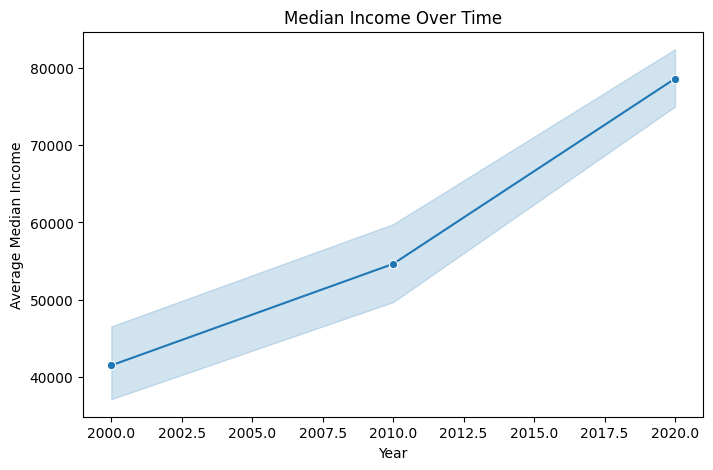

In [13]:
# median income over time

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='year', y='median_income', estimator='mean', marker='o')
plt.title('Median Income Over Time')
plt.xlabel('Year')
plt.ylabel('Average Median Income')
plt.show()

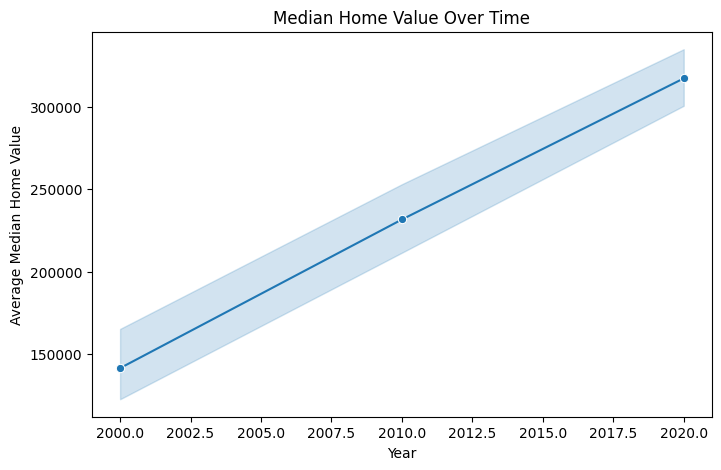

In [14]:
# median home value over time

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='year', y='median_home_value', estimator='mean', marker='o')
plt.title('Median Home Value Over Time')
plt.xlabel('Year')
plt.ylabel('Average Median Home Value')
plt.show()

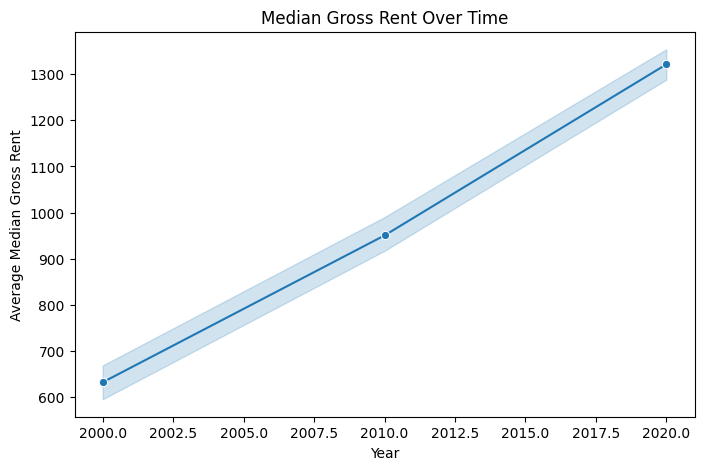

In [15]:
# median gross rent over time

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='year', y='median_gross_rent', estimator='mean', marker='o')
plt.title('Median Gross Rent Over Time')
plt.xlabel('Year')
plt.ylabel('Average Median Gross Rent')
plt.show()

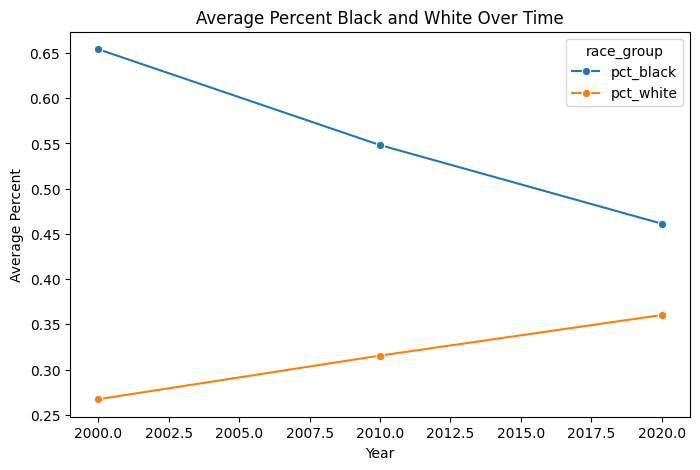

In [16]:
# percent black and percent white over time

race_trend = df.groupby('year')[['pct_black', 'pct_white']].mean().reset_index()

race_long = race_trend.melt(
    id_vars='year',
    value_vars=['pct_black', 'pct_white'],
    var_name='race_group',
    value_name='percent'
)

plt.figure(figsize=(8,5))
sns.lineplot(data=race_long, x='year', y='percent', hue='race_group', marker='o')
plt.title('Average Percent Black and White Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent')
plt.show()

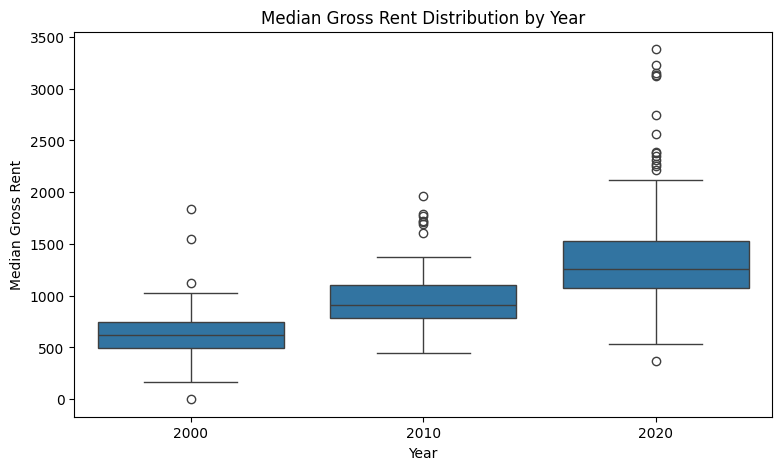

In [17]:
# rent distribution by year

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='year', y='median_gross_rent')
plt.title('Median Gross Rent Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Median Gross Rent')
plt.show()

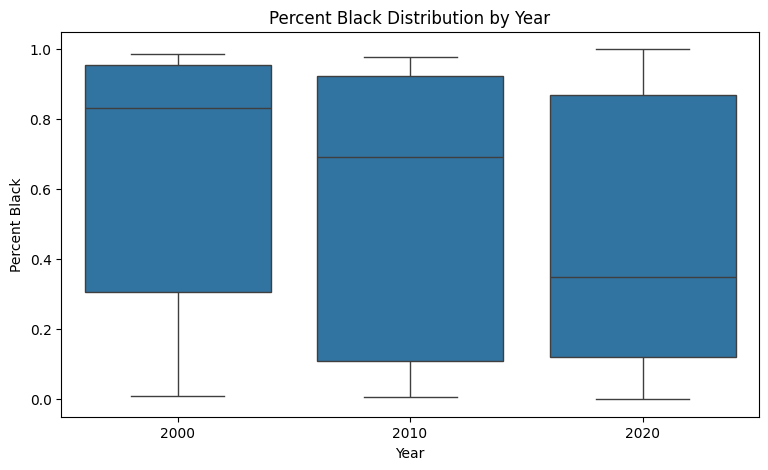

In [18]:
# percent black distribution by year

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='year', y='pct_black')
plt.title('Percent Black Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Percent Black')
plt.show()

## **Visual Interpretation**

The trend charts show a steady increase in income, home values, and rent across the three time points. The boxplots also show that the spread of housing costs changes over time, meaning some tracts became much more expensive than others.

The race trend is especially important for my capstone. The average percent Black declines over time while the average percent White increases. This supports the displacement and neighborhood transformation part of the story.

The visuals make the timeline clearer because they show the change instead of flattening all years into one summary.


# **4. Distance Group Analysis by Year**

Next, I looked at distance groups by year. This helps answer whether the relationship between BeltLine proximity and neighborhood change looks different in 2000, 2010, and 2020.


In [19]:
# average values by year and distance group

distance_year_summary = df.groupby(['year', 'distance_group'])[
    ['median_income', 'median_home_value', 'median_gross_rent',
     'pct_black', 'pct_white', 'poverty_rate', 'pct_renter']
].mean()

distance_year_summary

median_income  median_home_value  median_gross_rent  \
year distance_group                                                        
2000 0-0.5 miles      32575.956522      149469.565217         606.086957   
     0.5-1 mile       26336.866667       95600.000000         492.533333   
     1-1.5 miles      27535.200000      109770.000000         453.800000   
     1.5-3 miles      36993.130435      134339.130435         587.478261   
     3-5 miles        42361.040000      145248.000000         636.080000   
     5-10 miles       52830.483871      143116.129032         763.600000   
     10+ miles        84857.428571      264028.571429         842.285714   
2010 0-0.5 miles      42425.227273      212831.818182         891.590909   
     0.5-1 mile       36589.857143      181278.571429         791.500000   
     1-1.5 miles      44213.416667      248620.000000         964.888889   
     1.5-3 miles      48866.375000      250220.833333         855.250000   
     3-5 miles        52633.000000      236500.000000         931.424242   
     5-10 miles       55334.222222      211490.740741         963.250000   
     10+ miles        80844.193548      279823.333333        1151.892857   
2020 0-0.5 miles      79679.025000      408230.769231        1317.375000   
     0.5-1 mile       59668.000000      316869.444444        1228.000000   
     1-1.5 miles      64596.454545      321705.000000        1248.130435   
     1.5-3 miles      75976.104167      348137.777778        1304.083333   
     3-5 miles        78666.903226      374772.727273        1286.281250   
     5-10 miles       69452.213235      260212.878788        1263.184615   
     10+ miles        92886.777108      309188.819876        1436.078571   

                     pct_black  pct_white  poverty_rate  pct_renter  
year distance_group                                                  
2000 0-0.5 miles      0.666246   0.269112      0.255539    0.573637  
     0.5-1 mile       0.803862   0.153838      0.356316    0.622141  
     1-1.5 miles      0.777936   0.179223      0.341330    0.765467  
     1.5-3 miles      0.659428   0.256320      0.268874    0.519419  
     3-5 miles        0.707879   0.234217      0.201864    0.424472  
     5-10 miles       0.547910   0.319537      0.123347    0.412590  
     10+ miles        0.378972   0.550596      0.043241    0.184486  
2010 0-0.5 miles      0.608070   0.312181      0.316547    0.528086  
     0.5-1 mile       0.743570   0.196698      0.299503    0.587093  
     1-1.5 miles      0.557437   0.324090      0.276350    0.649582  
     1.5-3 miles      0.565735   0.321382      0.261309    0.527258  
     3-5 miles        0.562040   0.304527      0.217142    0.465083  
     5-10 miles       0.536732   0.283156      0.191818    0.447039  
     10+ miles        0.405654   0.431862      0.092378    0.298806  
2020 0-0.5 miles      0.396824   0.471667      0.166298    0.531164  
     0.5-1 mile       0.473570   0.394314      0.225896    0.638423  
     1-1.5 miles      0.459331   0.385997      0.256371    0.613338  
     1.5-3 miles      0.435035   0.422819      0.201130    0.541394  
     3-5 miles        0.426488   0.394647      0.154431    0.454050  
     5-10 miles       0.522814   0.278095      0.146885    0.467535  
     10+ miles        0.445470   0.356593      0.092215    0.365186

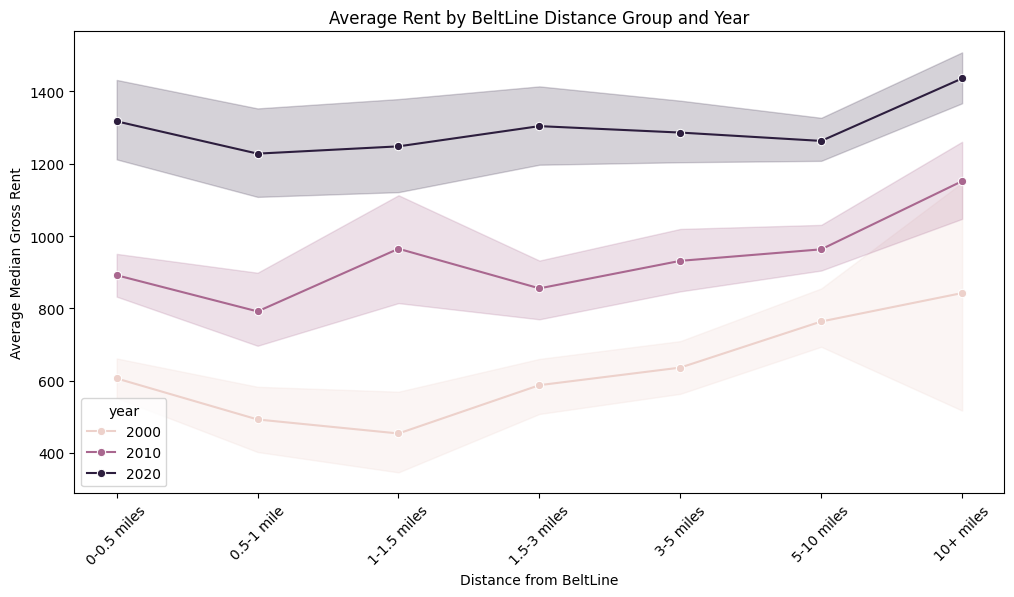

In [20]:
# rent by distance group and year

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='distance_group',
    y='median_gross_rent',
    hue='year',
    estimator='mean',
    marker='o'
)
plt.title('Average Rent by BeltLine Distance Group and Year')
plt.xlabel('Distance from BeltLine')
plt.ylabel('Average Median Gross Rent')
plt.xticks(rotation=45)
plt.show()

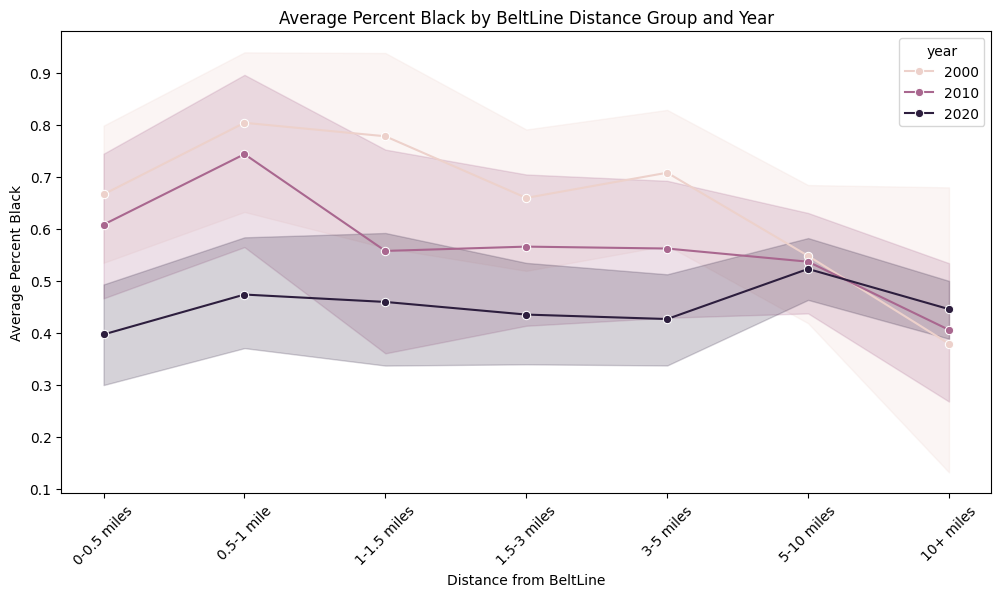

In [21]:
# percent black by distance group and year

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='distance_group',
    y='pct_black',
    hue='year',
    estimator='mean',
    marker='o'
)
plt.title('Average Percent Black by BeltLine Distance Group and Year')
plt.xlabel('Distance from BeltLine')
plt.ylabel('Average Percent Black')
plt.xticks(rotation=45)
plt.show()

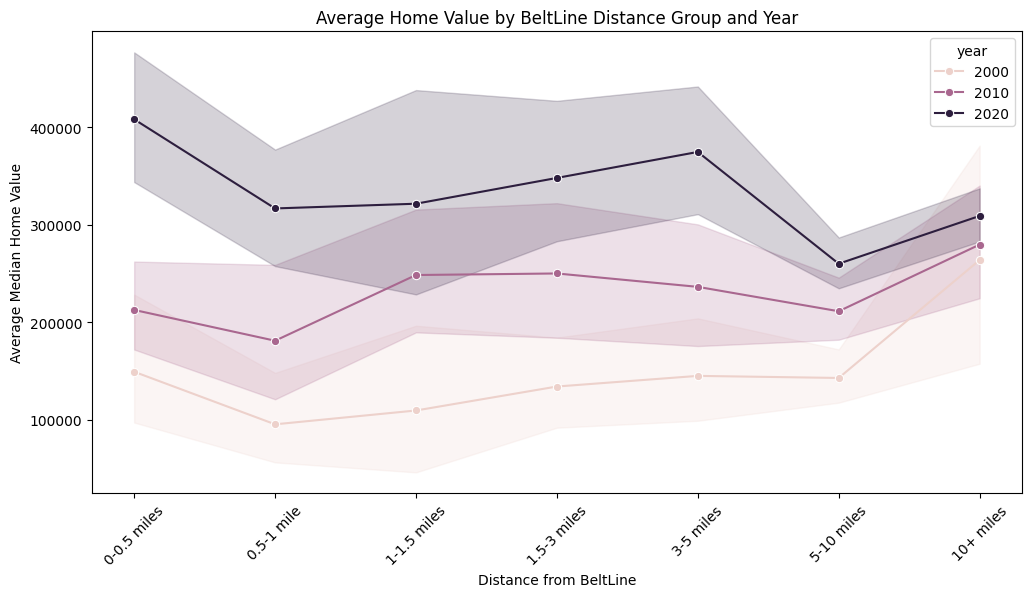

In [22]:
# home value by distance group and year

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='distance_group',
    y='median_home_value',
    hue='year',
    estimator='mean',
    marker='o'
)
plt.title('Average Home Value by BeltLine Distance Group and Year')
plt.xlabel('Distance from BeltLine')
plt.ylabel('Average Median Home Value')
plt.xticks(rotation=45)
plt.show()

## **Distance Group Interpretation by Year**

This section is important because it connects the timeline to space. It shows that the BeltLine relationship is not just about one moment in time. The patterns shift across 2000, 2010, and 2020.

The distance group charts show how rent, home value, and percent Black vary across distance bands. This helps show where redevelopment pressure may be strongest and how that changed over time.

The results also remind me not to oversimplify. Distance matters, but Atlanta neighborhoods have their own histories. So the analysis needs to consider both time and distance together.


# **5. Correlation Analysis by Year**

The correlation matrix helps show how variables move together. Since this project is about change over time, I created separate correlation matrices for 2000, 2010, and 2020.


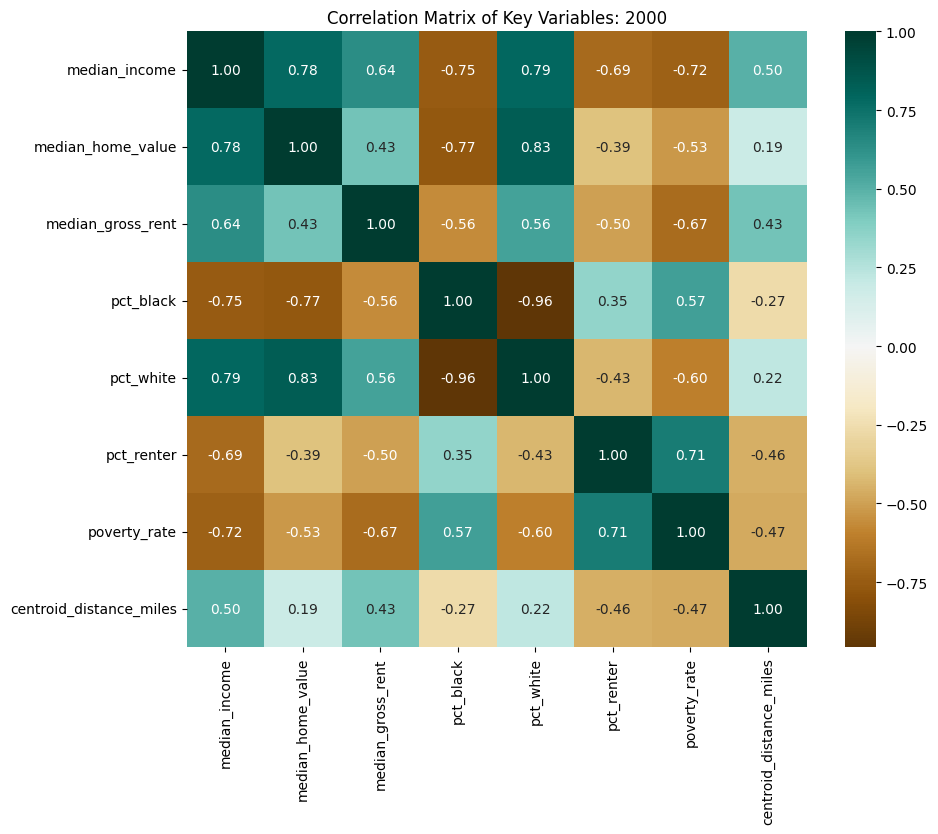

In [23]:
# variables for correlation

corr_vars = [
    'median_income',
    'median_home_value',
    'median_gross_rent',
    'pct_black',
    'pct_white',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles'
]

# correlation matrix for 2000
corr_2000 = df_2000[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_2000, annot=True, cmap='BrBG', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Variables: 2000')
plt.show()

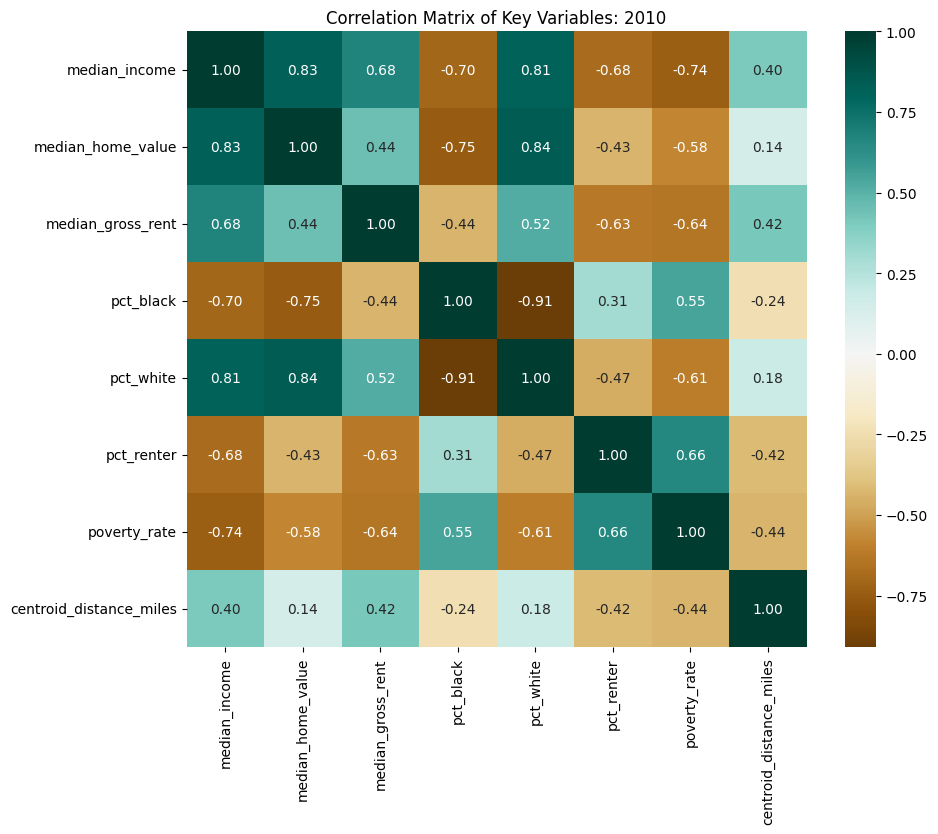

In [24]:
# correlation matrix for 2010

corr_2010 = df_2010[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_2010, annot=True, cmap='BrBG', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Variables: 2010')
plt.show()

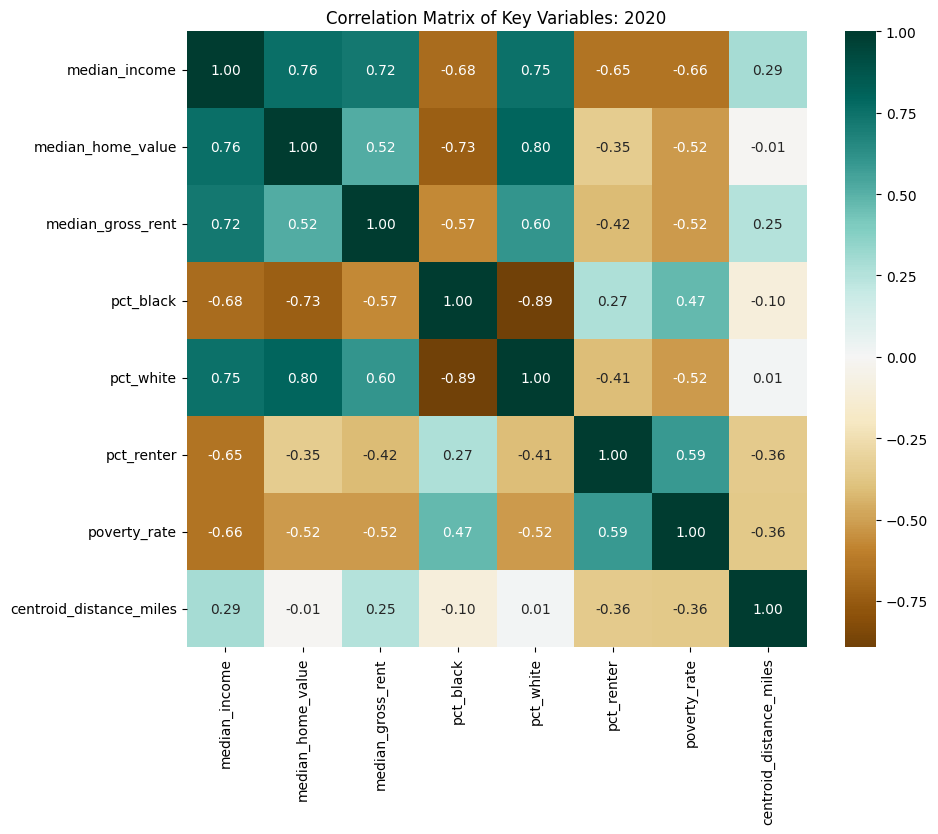

In [25]:
# correlation matrix for 2020

corr_2020 = df_2020[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_2020, annot=True, cmap='BrBG', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Variables: 2020')
plt.show()

## **Correlation Interpretation by Year**

The year-specific correlations show how the relationships changed across the timeline.

In 2000, the correlation between median income and rent is **0.638**. In 2010, it is **0.676**, and in 2020 it is **0.719**. This shows that income and rent are related across the full timeline.

For percent Black and median income, the correlation is **-0.746** in 2000, **-0.702** in 2010, and **-0.679** in 2020.

This matters because it shows that race and income are connected in the dataset, but the strength of that relationship can shift over time. That is why it would have been misleading to only use one combined correlation matrix for all years.


# **6. Hypothesis Testing by Year**

For the formal testing section, I ran tests by year instead of combining all years together.

I used:
- T-tests to compare tracts within 1 mile of the BeltLine to tracts farther than 1 mile
- ANOVA to compare multiple distance groups within each year
- Pearson correlation tests by year


## **T-Test: Rent Near the BeltLine vs Farther Away by Year**

**H0:** There is no difference in median gross rent between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.

**H1:** There is a difference in median gross rent between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.


In [26]:
# t-tests for rent within 1 mile vs farther than 1 mile by year

from scipy.stats import ttest_ind

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]
    near = temp[temp['centroid_distance_miles'] <= 1]['median_gross_rent'].dropna()
    far = temp[temp['centroid_distance_miles'] > 1]['median_gross_rent'].dropna()

    t_stat, p_value = ttest_ind(near, far, equal_var=False)

    print('\nYear:', yr)
    print('near 1 mile mean rent:', near.mean())
    print('farther than 1 mile mean rent:', far.mean())
    print('t-statistic:', t_stat)
    print('p-value:', p_value)


Year: 2000
near 1 mile mean rent: 561.2631578947369
farther than 1 mile mean rent: 660.5894736842105
t-statistic: -2.6569964981691467
p-value: 0.009124788274456279

Year: 2010
near 1 mile mean rent: 852.6666666666666
farther than 1 mile mean rent: 974.582191780822
t-statistic: -3.2946232665558957
p-value: 0.0014843855410103387

Year: 2020
near 1 mile mean rent: 1273.253164556962
farther than 1 mile mean rent: 1330.5925925925926
t-statistic: -1.2267399055617445
p-value: 0.22250086155635831


## **Rent T-Test Interpretation by Year**

In 2000, the average rent within 1 mile of the BeltLine was **$561**, compared to **$661** farther than 1 mile. The p-value was **0.009**.

In 2010, the average rent within 1 mile was **$853**, compared to **$975** farther than 1 mile. The p-value was **0.001**.

In 2020, the average rent within 1 mile was **$1,273**, compared to **$1,331** farther than 1 mile. The p-value was **0.223**.

This is helpful because it shows how the near/far rent gap changes across time. It also shows that a simple near/far test does not tell the whole story by itself, which is why I also use ANOVA across multiple distance groups.


## **T-Test: Home Value Near the BeltLine vs Farther Away by Year**

**H0:** There is no difference in median home value between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.

**H1:** There is a difference in median home value between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.


In [27]:
# t-tests for home value within 1 mile vs farther than 1 mile by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]
    near = temp[temp['centroid_distance_miles'] <= 1]['median_home_value'].dropna()
    far = temp[temp['centroid_distance_miles'] > 1]['median_home_value'].dropna()

    t_stat, p_value = ttest_ind(near, far, equal_var=False)

    print('\nYear:', yr)
    print('near 1 mile mean home value:', near.mean())
    print('farther than 1 mile mean home value:', far.mean())
    print('t-statistic:', t_stat)
    print('p-value:', p_value)


Year: 2000
near 1 mile mean home value: 128205.26315789473
farther than 1 mile mean home value: 146911.45833333334
t-statistic: -0.7293626712488418
p-value: 0.46864122882926984

Year: 2010
near 1 mile mean home value: 200561.11111111112
farther than 1 mile mean home value: 239164.66666666666
t-statistic: -1.646547278472276
p-value: 0.1045209526119905

Year: 2020
near 1 mile mean home value: 364377.3333333333
farther than 1 mile mean home value: 308874.5283018868
t-statistic: 2.109080449001301
p-value: 0.03743107425474228


## **Home Value T-Test Interpretation by Year**

In 2000, the average home value within 1 mile was **$128,205**, compared to **$146,911** farther than 1 mile. The p-value was **0.469**.

In 2010, the average home value within 1 mile was **$200,561**, compared to **$239,165** farther than 1 mile. The p-value was **0.105**.

In 2020, the average home value within 1 mile was **$364,377**, compared to **$308,875** farther than 1 mile. The p-value was **0.037**.

This test is important because home value is one of the clearest indicators of redevelopment pressure. Rising home values can benefit owners, but they can also make neighborhoods less accessible to renters and lower-income residents.


## **T-Test: Percent Black Near the BeltLine vs Farther Away by Year**

**H0:** There is no difference in average percent Black between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.

**H1:** There is a difference in average percent Black between tracts within 1 mile of the BeltLine and tracts farther than 1 mile for that year.


In [28]:
# t-tests for pct black within 1 mile vs farther than 1 mile by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]
    near = temp[temp['centroid_distance_miles'] <= 1]['pct_black'].dropna()
    far = temp[temp['centroid_distance_miles'] > 1]['pct_black'].dropna()

    t_stat, p_value = ttest_ind(near, far, equal_var=False)

    print('\nYear:', yr)
    print('near 1 mile mean pct black:', near.mean())
    print('farther than 1 mile mean pct black:', far.mean())
    print('t-statistic:', t_stat)
    print('p-value:', p_value)


Year: 2000
near 1 mile mean pct black: 0.7205680489745899
farther than 1 mile mean pct black: 0.6279291073625402
t-statistic: 1.3947997343880734
p-value: 0.1672421903250053

Year: 2010
near 1 mile mean pct black: 0.6607648656677629
farther than 1 mile mean pct black: 0.5222255651141862
t-statistic: 2.147705972391595
p-value: 0.036044959113297546

Year: 2020
near 1 mile mean pct black: 0.43567059364550476
farther than 1 mile mean pct black: 0.4659067155779982
t-statistic: -0.7346656375070849
p-value: 0.4640126555346962


## **Percent Black T-Test Interpretation by Year**

In 2000, the average percent Black within 1 mile was **72.1%**, compared to **62.8%** farther than 1 mile. The p-value was **0.167**.

In 2010, the average percent Black within 1 mile was **66.1%**, compared to **52.2%** farther than 1 mile. The p-value was **0.036**.

In 2020, the average percent Black within 1 mile was **43.6%**, compared to **46.6%** farther than 1 mile. The p-value was **0.464**.

This test directly connects to the race and displacement part of the capstone. The point is not only whether the BeltLine is associated with higher prices, but whether the racial composition around it changed across time.


# **7. ANOVA by Year**

The t-tests compare only two groups: within 1 mile and farther than 1 mile. But the BeltLine effect may not be that simple. ANOVA lets me compare multiple distance groups within each year.


## **ANOVA: Rent by Distance Group and Year**

**H0:** Average rent is the same across all BeltLine distance groups for that year.

**H1:** At least one distance group has a different average rent for that year.


In [29]:
# anova for rent across distance groups by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]

    groups = [
        group['median_gross_rent'].dropna().values
        for name, group in temp.groupby('distance_group')
        if len(group['median_gross_rent'].dropna()) > 1
    ]

    f_stat, p_value = f_oneway(*groups)

    print('\nYear:', yr)
    print('F-statistic:', f_stat)
    print('p-value:', p_value)


Year: 2000
F-statistic: 5.359469967103526
p-value: 5.864772783317551e-05

Year: 2010
F-statistic: 5.287721646773611
p-value: 4.925575580113295e-05

Year: 2020
F-statistic: 3.2981630608017345
p-value: 0.0034387183853159804


## **Rent ANOVA Interpretation by Year**

For rent by distance group, the ANOVA p-value was **< 0.001** in 2000, **< 0.001** in 2010, and **0.003** in 2020.

This test is stronger than the simple near/far t-test because it compares more than two distance bands. That matters because redevelopment pressure does not always stop exactly at 1 mile.

The ANOVA results help show whether rent differs across space within each year.


## **ANOVA: Percent Black by Distance Group and Year**

**H0:** Average percent Black is the same across all BeltLine distance groups for that year.

**H1:** At least one distance group has a different average percent Black for that year.


In [30]:
# anova for percent black across distance groups by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]

    groups = [
        group['pct_black'].dropna().values
        for name, group in temp.groupby('distance_group')
        if len(group['pct_black'].dropna()) > 1
    ]

    f_stat, p_value = f_oneway(*groups)

    print('\nYear:', yr)
    print('F-statistic:', f_stat)
    print('p-value:', p_value)


Year: 2000
F-statistic: 1.915350355983892
p-value: 0.08318523071423464

Year: 2010
F-statistic: 1.5317985120284625
p-value: 0.1698993084227624

Year: 2020
F-statistic: 1.085885693520465
p-value: 0.3695962988895188


## **Percent Black ANOVA Interpretation by Year**

For percent Black by distance group, the ANOVA p-value was **0.083** in 2000, **0.170** in 2010, and **0.370** in 2020.

This is important because it shows whether racial composition differs across BeltLine distance groups within each time period. If the p-value is below 0.05, that means at least one distance group has a significantly different average percent Black.

This supports the larger point that race and space are connected in the BeltLine story.


# **8. Pearson Correlation Tests by Year**

Pearson correlation tests whether two numeric variables have a statistically significant linear relationship. I ran these by year to avoid mixing time periods together.


In [31]:
# pearson correlation tests by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr]

    income_rent = temp[['median_income', 'median_gross_rent']].dropna()
    black_income = temp[['pct_black', 'median_income']].dropna()
    distance_home = temp[['centroid_distance_miles', 'median_home_value']].dropna()

    r1, p1 = pearsonr(income_rent['median_income'], income_rent['median_gross_rent'])
    r2, p2 = pearsonr(black_income['pct_black'], black_income['median_income'])
    r3, p3 = pearsonr(distance_home['centroid_distance_miles'], distance_home['median_home_value'])

    print('\nYear:', yr)
    print('income vs rent:', r1, p1)
    print('pct black vs income:', r2, p2)
    print('distance vs home value:', r3, p3)


Year: 2000
income vs rent: 0.6382288537335816 1.4184894074863526e-16
pct black vs income: -0.7463053985716966 4.264287205943341e-25
distance vs home value: 0.18644322180267076 0.031008256497880107

Year: 2010
income vs rent: 0.675788363740467 1.2456460544415384e-25
pct black vs income: -0.7024087552280903 1.4311085021651446e-29
distance vs home value: 0.14256908866049825 0.05223362934117213

Year: 2020
income vs rent: 0.7194529786414022 2.2558139539293517e-77
pct black vs income: -0.6786053207923487 1.7284753478903816e-70
distance vs home value: -0.00920670553715567 0.8374543152118001


## **Pearson Correlation Interpretation by Year**

For income and rent, the correlation was **0.638** in 2000, **0.676** in 2010, and **0.719** in 2020.

For percent Black and median income, the correlation was **-0.746** in 2000, **-0.702** in 2010, and **-0.679** in 2020.

For distance and home value, the correlation was **0.186** in 2000, **0.143** in 2010, and **-0.009** in 2020.

Running these by year makes the analysis more accurate because the relationship between housing, race, and distance can change over time.


# **9. OLS Regression by Year**

I used OLS regression to see how much rent can be explained by income, race, poverty, and distance from the BeltLine in each year.

The dependent variable is:

`median_gross_rent`

The independent variables are:
- `median_income`
- `pct_black`
- `poverty_rate`
- `centroid_distance_miles`


In [32]:
# ols regression by year

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr][
        ['median_gross_rent', 'median_income', 'pct_black',
         'poverty_rate', 'centroid_distance_miles']
    ].dropna()

    X = temp[
        ['median_income', 'pct_black', 'poverty_rate',
         'centroid_distance_miles']
    ]

    y = temp['median_gross_rent']

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print('\n==============================')
    print('YEAR:', yr)
    print('==============================')
    print(model.summary())


YEAR: 2000
                            OLS Regression Results                            
Dep. Variable:      median_gross_rent   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     35.37
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           7.04e-20
Time:                        15:46:11   Log-Likelihood:                -865.63
No. Observations:                 133   AIC:                             1741.
Df Residuals:                     128   BIC:                             1756.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const         

## **OLS Regression Interpretation by Year**

The OLS results show how the relationship between rent and the predictors changes over time.

In 2000, the model had R-squared **0.525**, income coefficient **0.0011**, distance coefficient **9.19**.

In 2010, the model had R-squared **0.521**, income coefficient **0.0036**, distance coefficient **7.94**.

In 2020, the model had R-squared **0.550**, income coefficient **0.0057**, distance coefficient **10.02**.

This is important because rent is not being explained by one factor alone. Income, poverty, race, and distance all interact with Atlanta’s neighborhood history. The year-by-year regression helps avoid flattening the timeline into one overall model.


# **10. Pre-ML Data Diagnosis by Year**

Before machine learning, I need to check for data problems that could affect model performance.

This includes:
- missing values
- outliers
- multicollinearity
- class imbalance

Since this project is about time, I also check these issues by year.


## **Missing Values by Year**

In [33]:
# missing values by year

missing_by_year = df.groupby('year').apply(lambda x: x.isnull().sum())

missing_by_year

,tract_id,tract_name,total_pop,median_income,median_home_value,median_gross_rent,occupied_units,owner_units,renter_units,hispanic_pop,white_pop,black_pop,poverty_universe,below_poverty,poverty_rate,year,centroid_distance_miles,beltline_half_mile,beltline_one_mile,beltline_three_miles,pct_white,pct_black,pct_hispanic,pct_renter,distance_group
year,,,,,,,,,,,,,,,,,,,,,,,,,
2000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2010,0,0,0,2,6,10,0,0,0,0,0,0,3,3,4,0,0,0,0,0,0,0,0,1,0
2020,0,0,0,15,29,44,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0


## **Missing Values Interpretation**

Checking missing values by year matters because missingness may not be evenly distributed across 2000, 2010, and 2020.

For this notebook, I did not drop every missing row upfront. Instead, I use `dropna()` inside each statistical test or model so each section only removes the rows needed for that specific analysis.

This keeps more data available and avoids deleting useful rows just because one variable is missing.


## **Outlier Review by Year**

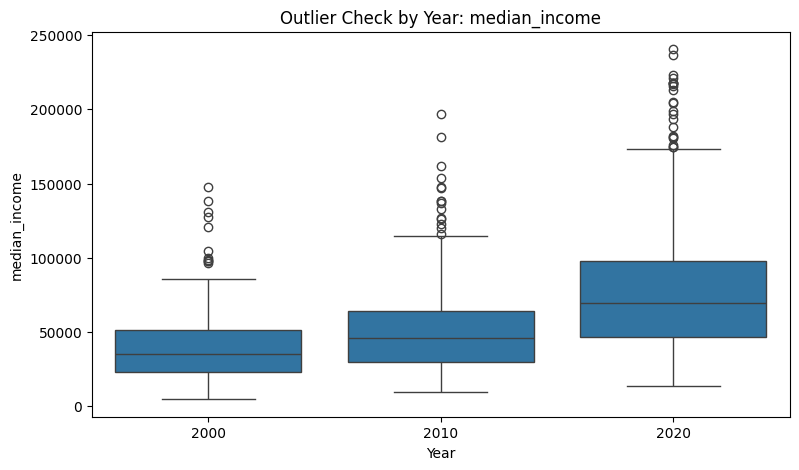

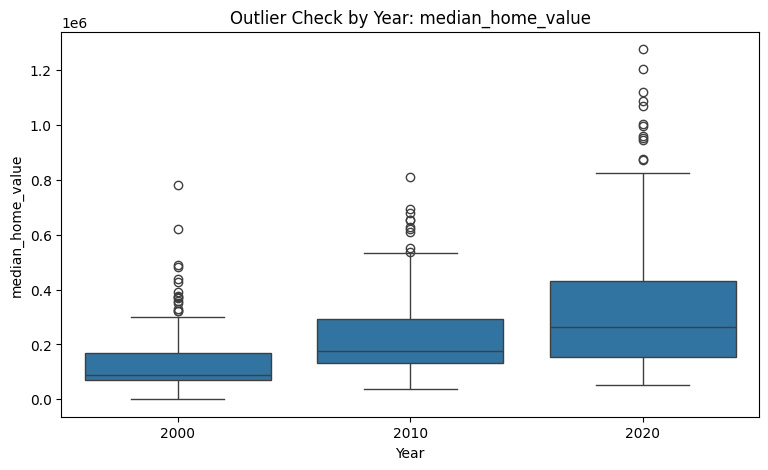

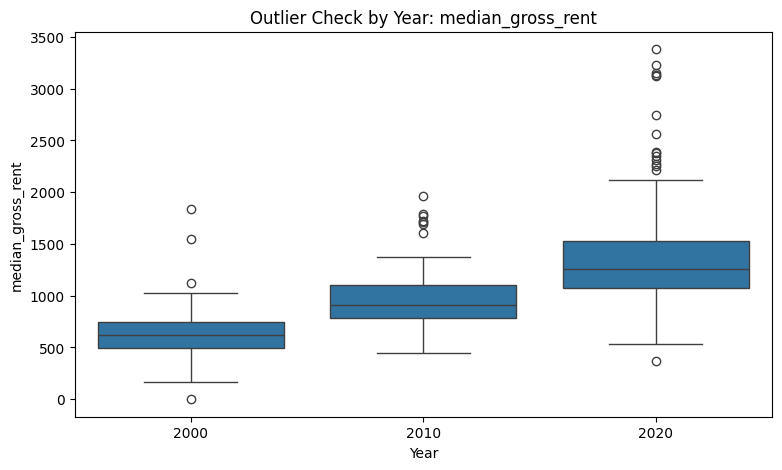

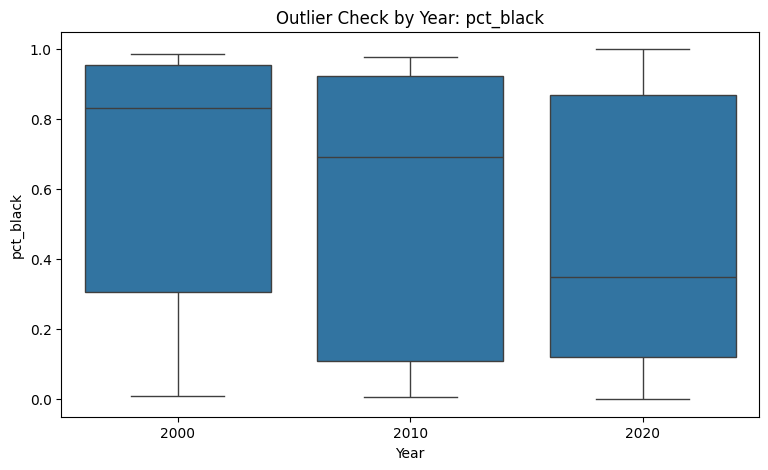

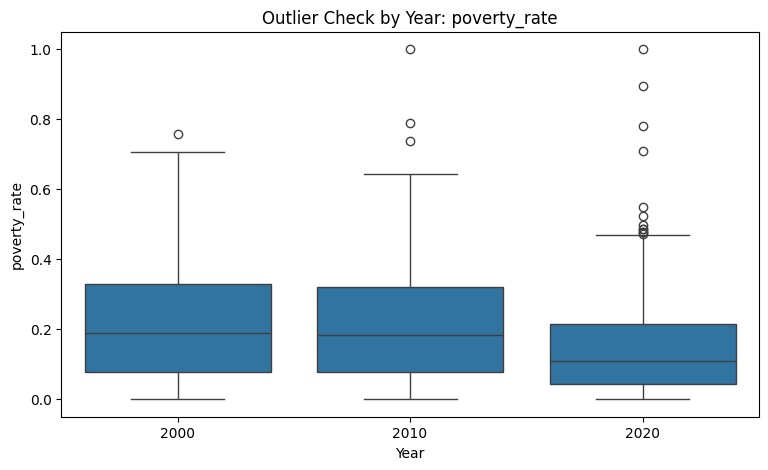

In [34]:
# outlier boxplots by year

outlier_vars = [
    'median_income',
    'median_home_value',
    'median_gross_rent',
    'pct_black',
    'poverty_rate'
]

for col in outlier_vars:
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df, x='year', y=col)
    plt.title(f'Outlier Check by Year: {col}')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.show()

## **Outlier Interpretation by Year**

There are outliers in income, home value, rent, and poverty. I kept these outliers because they represent real differences between Atlanta neighborhoods.

For this project, outliers are not just noise. They help show inequality. A very high home value tract or a very high poverty tract is part of the story I am studying.

For machine learning, I may later test transformations or robust models, but I would not delete these values without a strong reason.


## **Multicollinearity by Year**

Multicollinearity happens when independent variables are too strongly related to each other. I checked VIF by year because relationships between features can change over time.


In [35]:
# vif by year

features = [
    'median_income',
    'median_home_value',
    'median_gross_rent',
    'pct_black',
    'pct_white',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles'
]

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr][features].replace([np.inf, -np.inf], np.nan).dropna()

    vif_results = pd.DataFrame()
    vif_results['feature'] = features
    vif_results['VIF'] = [
        variance_inflation_factor(temp.values, i)
        for i in range(temp.shape[1])
    ]

    print('\nYEAR:', yr)
    display(vif_results)


YEAR: 2000


,feature,VIF
0,median_income,21.749686
1,median_home_value,9.573510
2,median_gross_rent,15.521993
3,pct_black,15.438986
4,pct_white,15.516796
5,pct_renter,11.045094
6,poverty_rate,8.227759
7,centroid_distance_miles,3.680232



YEAR: 2010


,feature,VIF
0,median_income,31.208135
1,median_home_value,19.256378
2,median_gross_rent,25.027077
3,pct_black,12.749869
4,pct_white,15.589028
5,pct_renter,7.730438
6,poverty_rate,7.409805
7,centroid_distance_miles,3.901629



YEAR: 2020


,feature,VIF
0,median_income,25.037005
1,median_home_value,12.057994
2,median_gross_rent,28.118572
3,pct_black,6.993778
4,pct_white,13.296253
5,pct_renter,7.527003
6,poverty_rate,5.171664
7,centroid_distance_miles,3.495362


## **Multicollinearity Interpretation by Year**

The VIF results show that income, home value, and rent overlap strongly, especially because they all measure related parts of neighborhood economic conditions.

In 2000, median income had a VIF of **21.75**. In 2010, it was **31.21**. In 2020, it was **25.04**.

This matters because if I use rent as the target variable, I should not also use rent as a predictor. I also need to be careful about including both income and home value in the same model because they may be explaining similar things.

A cleaner feature set for future modeling is:
- median income
- percent Black
- percent renter
- poverty rate
- distance from the BeltLine


In [36]:
# cleaned vif by year after removing home value and rent from predictors

fixed_features = [
    'median_income',
    'pct_black',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles'
]

for yr in [2000, 2010, 2020]:
    temp = df[df['year'] == yr][fixed_features].replace([np.inf, -np.inf], np.nan).dropna()

    fixed_vif_results = pd.DataFrame()
    fixed_vif_results['feature'] = fixed_features
    fixed_vif_results['VIF'] = [
        variance_inflation_factor(temp.values, i)
        for i in range(temp.shape[1])
    ]

    print('\nYEAR:', yr)
    display(fixed_vif_results)


YEAR: 2000


,feature,VIF
0,median_income,3.259183
1,pct_black,5.310343
2,pct_renter,7.684120
3,poverty_rate,7.405344
4,centroid_distance_miles,3.195751



YEAR: 2010


,feature,VIF
0,median_income,2.828755
1,pct_black,4.241764
2,pct_renter,5.951373
3,poverty_rate,7.114202
4,centroid_distance_miles,2.934572



YEAR: 2020


,feature,VIF
0,median_income,2.863048
1,pct_black,3.359928
2,pct_renter,4.771972
3,poverty_rate,4.526956
4,centroid_distance_miles,3.020366


## **Multicollinearity Fix**

After removing home value and rent from the predictor set, the features are cleaner for modeling. This does not mean home value and rent are unimportant. It means I need to be careful about using variables that are measuring the same underlying pattern.

For the machine learning section, I would use a cleaner set of features and avoid having the target variable also appear as a predictor.


## **Class Imbalance by Year**

For classification, I need to check whether the target variable is balanced. Here, I use `beltline_three_miles` as a possible classification target.


In [37]:
# class imbalance by year

df.groupby('year')['beltline_three_miles'].value_counts()

year  beltline_three_miles
2000  1.0                      71
      0.0                      63
2010  0.0                     119
      1.0                      73
2020  0.0                     373
      1.0                     155
Name: count, dtype: int64

In [38]:
# class percentages by year

df.groupby('year')['beltline_three_miles'].value_counts(normalize=True) * 100

year  beltline_three_miles
2000  1.0                     52.985075
      0.0                     47.014925
2010  0.0                     61.979167
      1.0                     38.020833
2020  0.0                     70.643939
      1.0                     29.356061
Name: proportion, dtype: float64

## **Class Imbalance Interpretation by Year**

The class balance is fairly consistent by year because each year has the same tract structure repeated across time.

For 2000, about **53.0%** of observations are within 3 miles of the BeltLine. For 2010, about **38.0%** are within 3 miles. For 2020, about **29.4%** are within 3 miles.

This is somewhat imbalanced, but not extreme. If I use this as a classification target, I would use a stratified train-test split and possibly class weights so the model does not mostly learn the larger class.


In [39]:
# example stratified train-test split for future classification

features_for_ml = [
    'median_income',
    'pct_black',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles',
    'year'
]

target = 'beltline_three_miles'

ml_df = df[features_for_ml + [target]].dropna()

X = ml_df[features_for_ml]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('training target balance:')
print(y_train.value_counts(normalize=True) * 100)

print('\ntesting target balance:')
print(y_test.value_counts(normalize=True) * 100)

training target balance:
beltline_three_miles
0.0    65.367316
1.0    34.632684
Name: proportion, dtype: float64

testing target balance:
beltline_three_miles
0.0    65.269461
1.0    34.730539
Name: proportion, dtype: float64


In [40]:
# example class weights if needed

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

class_weight_dict

{np.float64(0.0): np.float64(0.7649082568807339),
 np.float64(1.0): np.float64(1.4437229437229437)}

## **Class Imbalance Fix**

To handle class imbalance, I would use a stratified train-test split. This keeps the class proportions similar in both the training and testing data.

If the smaller class still performs poorly, I would try class weights. I would use class weights before SMOTE because this dataset is spatial and census-based, so synthetic observations could distort the geography.


# **11. Final Model-Ready Dataset**

This section creates a cleaned version of the dataset that can be used for the machine learning section of my capstone.

Since the project is about change over time, I keep `year` as a feature in the model-ready dataset.


In [41]:
# create model-ready dataset

model_features = [
    'median_income',
    'pct_black',
    'pct_renter',
    'poverty_rate',
    'centroid_distance_miles',
    'year'
]

model_target = 'beltline_three_miles'

model_ready = df[model_features + [model_target]].dropna()

model_ready.head()

,median_income,pct_black,pct_renter,poverty_rate,centroid_distance_miles,year,beltline_three_miles
0,96542.0,0.022995,0.280632,0.047138,1.533807,2000,1.0
1,56094.0,0.060055,0.579283,0.064161,1.297543,2000,1.0
2,73715.0,0.150445,0.321192,0.098678,1.724488,2000,1.0
3,47438.0,0.056497,0.518868,0.068788,0.880254,2000,1.0
4,28147.0,0.884483,0.510566,0.262642,0.889622,2000,1.0


In [42]:
# check final model-ready shape

model_ready.shape

(834, 7)

In [43]:
# scale numeric features for models that need scaling

scaler = StandardScaler()

scaled_features = scaler.fit_transform(model_ready[model_features])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=model_features
)

scaled_df[model_target] = model_ready[model_target].values

scaled_df.head()

,median_income,pct_black,pct_renter,poverty_rate,centroid_distance_miles,year,beltline_three_miles
0,0.685827,-1.326085,-0.743181,-0.866223,-0.895447,-1.927688,1.0
1,-0.266070,-1.225947,0.412595,-0.749666,-0.938411,-1.927688,1.0
2,0.148620,-0.981706,-0.586216,-0.513332,-0.860772,-1.927688,1.0
3,-0.469779,-1.235560,0.178789,-0.717987,-1.014295,-1.927688,1.0
4,-0.923771,1.001716,0.146662,0.609313,-1.012592,-1.927688,1.0


# **Final Summary**

This analysis shows that the BeltLine story is not just about redevelopment. It is also about cost, race, space, and time.

The strongest findings are:

- Across the full dataset, median income increased from **$41,502** in 2000 to **$78,605** in 2020.
- Across the full dataset, median rent increased from **$632** to **$1,321**.
- Within 3 miles of the BeltLine, median income increased from **$31,979** to **$71,021**.
- Within 3 miles of the BeltLine, median home value increased by **176.7%** from 2000 to 2020.
- Within 3 miles of the BeltLine, median gross rent increased by **130.7%** from 2000 to 2020.
- Within 3 miles, the average Black population share declined from **70.9%** to **43.9%**.
- Within 3 miles, the average White population share increased from **22.8%** to **42.2%**.
- The t-tests and ANOVA tests were run by year so the analysis matches the actual timeline of the capstone.
- The correlation and OLS regression sections were also separated by year, which avoids mixing 2000, 2010, and 2020 into one combined pattern.
- Multicollinearity was present, especially between income, home value, and rent, so the feature set needs to be cleaned before machine learning.
- The possible classification target is somewhat imbalanced, so stratified splitting and class weights should be considered.

Overall, the data supports my capstone argument: redevelopment around the BeltLine is connected to rising housing costs and demographic change over time. The pattern is not simple, but it is clear enough to show that proximity, race, housing costs, and time should be studied together.


# **Portfolio / GitHub Notes**

For my portfolio, this notebook should be uploaded directly into the `remideso.github.io` repository.

This notebook pulls the CSV directly from GitHub using:

```python
df = pd.read_csv('https://raw.githubusercontent.com/remideso/remideso.github.io/main/atlanta_spatial_final.csv')
```

Suggested file name:

```text
BeltLineCapstone.ipynb
```

Suggested README link:

```markdown
[View BeltLine Capstone Statistical Analysis](BeltLineCapstone.ipynb)
```

To show outputs on GitHub:
1. Open the notebook in Google Colab.
2. Run all cells.
3. Save a copy back to GitHub.
4. Open the notebook in GitHub and confirm charts/tables are visible.
